# Early-training success rate vs 65% criterion

Célia asked to check whether **FL_M01569519**, **MbL_M01569517** and **MbR_M01569518**
reached **65% success in their last two sessions** of early training. Each row of her
tables is one day (pooling the Bonsai sessions listed for it), so this reuses the same
`(training_day, session, min_trial, exclude_on)` spec shape as `TRAINING_DETAIL` and the
same `training_spec` / `filter_trials` helpers.

Output: success rate per training day, one coloured line per mouse (all six, shared Q_C
palette) plus a **black line pooling every trial from all animals** on each day, with a
dashed line at 65%, and a per-mouse table of the last-two-day success rates so the
"reached 65%?" question is answered as a number. Two further cells below repeat the same
per-mouse + pooled plot for the **Failure** and **Miss** rates (no 65% line - that
criterion is a success target).

Note (per Célia): FL's `2026-04-29T170501Z` is set `exclude_on=True` as a safety net -
she wasn't certain there were no ON (cue) trials that day, so any are dropped.

In [1]:
# Setup
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_conduit.qc import (
    qc_datastructure, training_spec, training_session_names, filter_trials,
)

# These are late-April training sessions, which live under the Training tree, so load
# from the common BonsaiOutput parent (depth=3, <tree>/<mouseID>/<day>/<session>) exactly
# like Test_success_rate.ipynb; include= still restricts to the sessions listed below.
ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput')

CRITERION = 0.65   # the success-rate criterion Célia is checking against

# Where the rendered SVGs are written (this qc/ folder, alongside the notebook).
SAVE_DIR = pathlib.Path('/home/sepi/dataconduit_workspace/data-conduit/src/data_conduit/qc')

In [2]:
# One row per day (repeat the day number to pool that day's sessions), transcribed from
# Célia's TSVs. Tuple = (training_day, session, min_trial, exclude_on).
CRITERION_DETAIL: dict[str, list[tuple[int, str, int, bool]]] = {
    'FL_M01569519': [
        (1, '2026-04-25T194933Z', 11, False),
        (1, '2026-04-25T200011Z', 11, False),
        (1, '2026-04-25T200705Z', 11, False),
        (1, '2026-04-25T201616Z', 11, False),
        (1, '2026-04-25T202109Z', 6, False),
        (2, '2026-04-28T172539Z', 21, False),
        (2, '2026-04-28T173816Z', 6, False),
        (2, '2026-04-28T174249Z', 6, False),
        (2, '2026-04-28T174922Z', 2, False),
        (3, '2026-04-29T170501Z', 11, True),
        (3, '2026-04-29T171313Z', 11, False),
        (3, '2026-04-29T172239Z', 11, False),
        (3, '2026-04-29T174637Z', 2, False),
        (4, '2026-05-11T125643Z', 16, False),
        (5, '2026-05-12T164637Z', 24, False),
        # (6, '2026-05-13T161503Z', 24, False),
        # (7, '2026-05-14T165819Z', 24, False),
    ],
    'FLR_M01569521': [
        (1, '2026-04-23T160907Z', 11, False),
        (2, '2026-04-25T190120Z', 11, False),   # day 2: COMBINE TWO SESSIONS
        (2, '2026-04-25T190915Z', 11, False),
        (3, '2026-04-28T124013Z',  6, False),   # day 3: COMBINE TWO SESSIONS
        (3, '2026-04-28T124547Z', 11, False),
        (4, '2026-04-29T161826Z', 11, False),
        (5, '2026-04-30T151438Z',  6, False),
    ],
    'FbR_M01569522': [
        (1, '2026-04-21T155201Z', 26, False),   # day 1: COMBINE TWO SESSIONS
        (1, '2026-04-21T162256Z',  6, False),
        (2, '2026-04-23T165237Z', 11, False),
        (3, '2026-04-25T181535Z', 11, False),   # day 3: COMBINE TWO SESSIONS
        (3, '2026-04-25T182521Z', 11, False),
        (4, '2026-04-28T163449Z', 21, False),   # day 4: COMBINE THREE SESSIONS
        (4, '2026-04-28T164540Z', 12, False),
        (4, '2026-04-28T165257Z', 16, False),
        (5, '2026-04-29T153239Z', 23, False),   # day 5: COMBINE TWO SESSIONS
        (5, '2026-04-29T155431Z', 14, False),
    ],
    'MbL_M01569517': [
        (1, '2026-05-16T165921Z', 24, False),
        (2, '2026-05-17T144445Z', 24, False),
        (3, '2026-05-19T091455Z', 24, False),
        (4, '2026-05-20T112502Z', 24, False),
        (5, '2026-05-21T120827Z', 24, False),
        (6, '2026-05-22T150830Z', 24, False),
        (7, '2026-05-28T154840Z', 24, False),
        (8, '2026-05-29T155941Z', 24, False),
    ],
    # Block-protocol mice: keep 24-to-end AND drop the mid-session ON (cue) trials.
    'MR_M01569515': [
        (1, '2026-05-12T150308Z', 24, True),
        (2, '2026-05-13T121852Z', 24, True),
        (3, '2026-05-14T122109Z', 24, True),
        (4, '2026-05-16T173516Z', 24, True),
    ],
    'MbR_M01569518': [
        (1, '2026-05-12T132304Z', 24, True),
        (2, '2026-05-13T135855Z', 24, True),
        (3, '2026-05-14T135225Z', 24, True),
        (4, '2026-05-16T155926Z', 24, True),
        (5, '2026-05-17T154506Z', 24, True),
        (6, '2026-05-19T110125Z', 24, True),
        (7, '2026-05-20T102711Z', 24, True),
    ],
}

In [3]:
# Helpers.
# Per-mouse colours: the shared Q_C palette used across the qc notebooks
# (Test_success_rate / Outcome_rate_plots) - F-named mice in pink shades, M-named in
# blue shades. Dict order sets the legend / plotting order.
DEFAULT_MOUSE_COLOURS = {
    'FLR_M01569521': '#f994b1',
    'FbR_M01569522': '#e53592',
    'FL_M01569519':  '#950041',
    'MR_M01569515':  '#73a9cf',
    'MbR_M01569518': '#2e7ebc',
    'MbL_M01569517': '#004cd9',
}


def make_outcome_df(trials, outcome_filters, *, group_cols, outcome_col='outcome'):
    """Per-group outcome counts and proportions (n_<name>, prop_<name>)."""
    group_cols = list(group_cols)
    out = trials.groupby(group_cols).size().rename('n_total').reset_index()
    for name, outcomes in outcome_filters.items():
        counts = (trials[trials[outcome_col].isin(outcomes)]
                  .groupby(group_cols).size().rename(f'n_{name}').reset_index())
        out = out.merge(counts, on=group_cols, how='left')
        out[f'n_{name}'] = out[f'n_{name}'].fillna(0).astype(int)
        out[f'prop_{name}'] = out[f'n_{name}'] / out['n_total']
    return out


def plot_criterion(trials, *, criterion=CRITERION, mouse_colours=DEFAULT_MOUSE_COLOURS,
                   mouse_col='mouseID', day_col='training_day', ax=None,
                   outcome_name='success', outcome_labels=('Success',),
                   show_criterion=True, line_alpha=0.3, line_width=4, marker_alpha=0.85):
    """Overlay each mouse's <outcome> rate per day, plus a black all-animals line.

    Per-mouse series follow the shared qc style: a thick, faint coloured line with
    solid, black-edged dots on top. The black line pools EVERY trial from ALL animals
    on a given training day (total matching / total trials that day), not the mean of
    the per-mouse rates. Set outcome_name / outcome_labels to plot a different outcome
    (e.g. 'failure', ['Failure']); show_criterion draws the dashed 65% line (only
    meaningful for success).
    """
    filt = {outcome_name: list(outcome_labels)}
    prop = f'prop_{outcome_name}'
    summary = make_outcome_df(trials, filt, group_cols=(mouse_col, day_col))
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5))
    else:
        fig = ax.figure
    for mouse in [m for m in mouse_colours if m in set(trials[mouse_col])]:
        s = summary[summary[mouse_col] == mouse].sort_values(day_col)
        ax.plot(s[day_col], s[prop], color=mouse_colours[mouse], alpha=line_alpha,
                linewidth=line_width, solid_capstyle='round', zorder=1)
        ax.scatter(s[day_col], s[prop], color=mouse_colours[mouse], alpha=marker_alpha,
                   edgecolor='black', linewidth=0.4, zorder=2, label=mouse)
    # All trials from all animals pooled per day (weighted by trial count).
    pooled = make_outcome_df(trials, filt, group_cols=(day_col,)).sort_values(day_col)
    ax.plot(pooled[day_col], pooled[prop], color='black', linewidth=2.5, marker='o',
            zorder=3, label='All animals')
    if show_criterion:
        ax.axhline(criterion, linestyle='--', color='crimson', linewidth=1.5,
                   zorder=0, label=f'{criterion:.0%} criterion')
    ax.set_xlabel('Training day', fontsize=14)
    ax.set_ylabel(f'{outcome_name.capitalize()} rate', fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_xticks(sorted(trials[day_col].unique()))
    ax.tick_params(axis='both', labelsize=12)
    title = f'Early-training {outcome_name} rate'
    if show_criterion:
        title += f' vs {criterion:.0%} criterion'
    ax.set_title(title, fontsize=15)
    # Open up the plot: drop the top / right box spines (qc-notebook style).
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.legend(fontsize=9)
    return fig, ax, summary


def last_n_days_summary(trials, *, n=2, criterion=CRITERION,
                        mouse_col='mouseID', day_col='training_day'):
    """Per-mouse success rate over the last n days, and whether it clears the criterion."""
    summary = make_outcome_df(trials, {'success': ['Success']}, group_cols=(mouse_col, day_col))
    rows = []
    for mouse, g in summary.groupby(mouse_col):
        last = g.sort_values(day_col).tail(n)
        rows.append({
            'mouseID': mouse,
            'last_days': last[day_col].tolist(),
            'last_rates': [round(r, 3) for r in last['prop_success']],
            f'mean_last{n}': round(last['prop_success'].mean(), 3),
            'every_day_>=criterion': bool((last['prop_success'] >= criterion).all()),
            'mean_>=criterion': bool(last['prop_success'].mean() >= criterion),
        })
    return pd.DataFrame(rows)

In [4]:
# Load only the listed sessions, then filter (reuses the training-spec helpers).
spec = training_spec(CRITERION_DETAIL)
datastructure = qc_datastructure(
    root=ROOT,
    depth=3,                                              # <tree>/<mouseID>/<day>/<session>
    level_names=('tree', 'mouseID', 'day'),
    streams=('events', 'nosepoke', 'soundcard', 'session_settings'),
    include=training_session_names(spec),
)
result = datastructure.load()
trials_filtered = filter_trials(result['trials'], spec)
trials_filtered


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
      mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
FLR_M01569521             1 2026-04-23T160907Z       74         11           64       False             0      64
FLR_M01569521             2 2026-04-25T190120Z       22         11           12       False             0      12
F

,trial_index,start_time,end_time,tz_triggered_time,outbound_start_time,outbound_end_time,inbound_start_time,inbound_end_time,TTT,TTP,...,outcome,LED,angle_offset,target_zone_size,session,tree,mouseID,day,training_day,day_trial_index
0,11,23009.675488,23021.869984,23016.854976,23009.675488,23016.854976,23016.854976,23021.869984,7.179488,5.015008,...,Miss,OFF,0.0,150.0,2026-04-23T160907Z,Training,FLR_M01569521,Day2,1,1
1,12,23021.869984,23030.656000,23027.952992,23021.869984,23027.952992,23027.952992,23030.656000,6.083008,2.703008,...,Success,OFF,NaN,150.0,2026-04-23T160907Z,Training,FLR_M01569521,Day2,1,2
2,13,23030.656000,23040.496480,23037.102976,23030.656000,23037.102976,23037.102976,23040.496480,6.446976,3.393504,...,Success,OFF,0.0,150.0,2026-04-23T160907Z,Training,FLR_M01569521,Day2,1,3
3,14,23040.496480,23051.965984,23046.953984,23040.496480,23046.953984,23046.953984,23051.965984,6.457504,5.012000,...,Miss,OFF,0.0,150.0,2026-04-23T160907Z,Training,FLR_M01569521,Day2,1,4
4,15,23051.965984,23066.218976,23061.202976,23051.965984,23061.202976,23061.202976,23066.218976,9.236992,5.016000,...,Miss,OFF,NaN,150.0,2026-04-23T160907Z,Training,FLR_M01569521,Day2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,88,8522.236992,8533.254496,8529.316992,8522.236992,8529.316992,8529.316992,8533.254496,7.080000,3.937504,...,Success,OFF,NaN,150.0,2026-05-20T102711Z,Training,MbR_M01569518,Day13,7,62
2117,89,8533.254496,8552.430496,8547.418976,8533.254496,8547.418976,8547.418976,8552.430496,14.164480,5.011520,...,Miss,OFF,0.0,150.0,2026-05-20T102711Z,Training,MbR_M01569518,Day13,7,63
2118,90,8552.430496,8565.830496,8560.817984,8552.430496,8560.817984,8560.817984,8565.830496,8.387488,5.012512,...,Miss,OFF,NaN,150.0,2026-05-20T102711Z,Training,MbR_M01569518,Day13,7,64
2119,91,8565.830496,8592.507488,8587.717984,8565.830496,8587.717984,8587.717984,8592.507488,21.887488,4.789504,...,Success,OFF,NaN,150.0,2026-05-20T102711Z,Training,MbR_M01569518,Day13,7,65


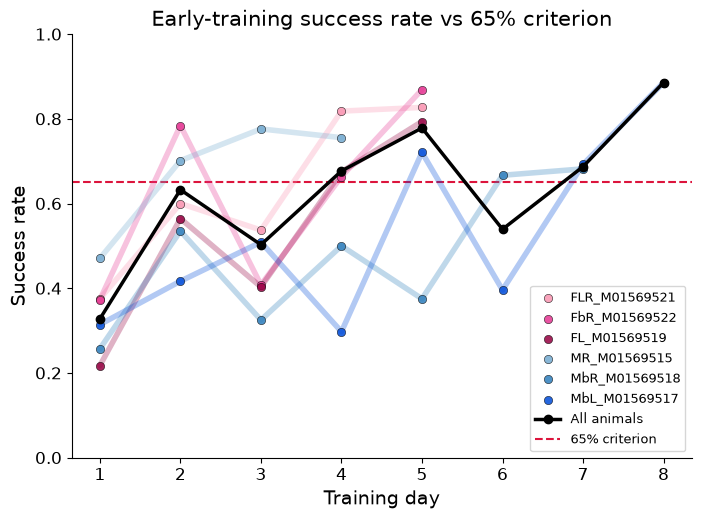

,mouseID,last_days,last_rates,mean_last2,every_day_>=criterion,mean_>=criterion
0,FLR_M01569521,"[4, 5]","[0.818, 0.827]",0.823,True,True
1,FL_M01569519,"[4, 5]","[0.675, 0.794]",0.734,True,True
2,FbR_M01569522,"[4, 5]","[0.664, 0.869]",0.766,True,True
3,MR_M01569515,"[3, 4]","[0.776, 0.756]",0.766,True,True
4,MbL_M01569517,"[7, 8]","[0.692, 0.886]",0.789,True,True
5,MbR_M01569518,"[6, 7]","[0.667, 0.682]",0.674,True,True


In [5]:
# Figure + the "did she reach 65%?" table.
fig, ax, summary = plot_criterion(trials_filtered)
fig.savefig(SAVE_DIR / 'criterion_success_rate.svg', bbox_inches='tight')
plt.show()
last_n_days_summary(trials_filtered, n=2)

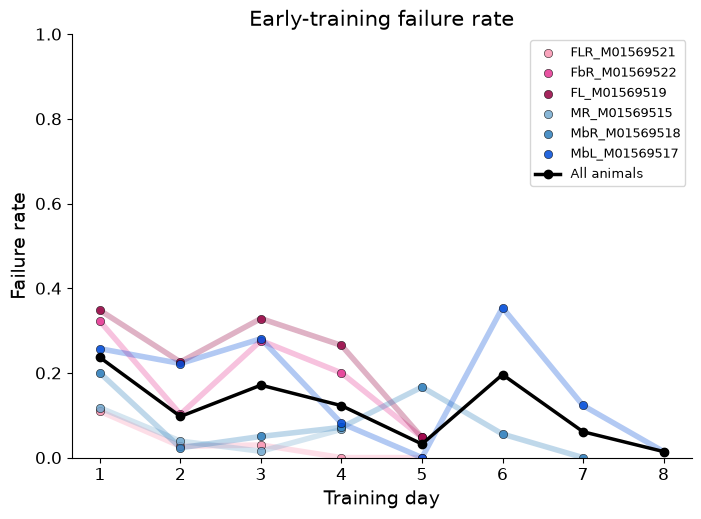

In [6]:
# Same plot for FAILURE rate (wrong-port pokes: Success=False with a port chosen).
# Coloured line per mouse plus the black all-animals-pooled line. No 65% line - that
# criterion is a success target, so it is not drawn here.
fig, ax, failure_summary = plot_criterion(
    trials_filtered, outcome_name='failure', outcome_labels=('Failure',), show_criterion=False,
)
fig.savefig(SAVE_DIR / 'criterion_failure_rate.svg', bbox_inches='tight')
plt.show()

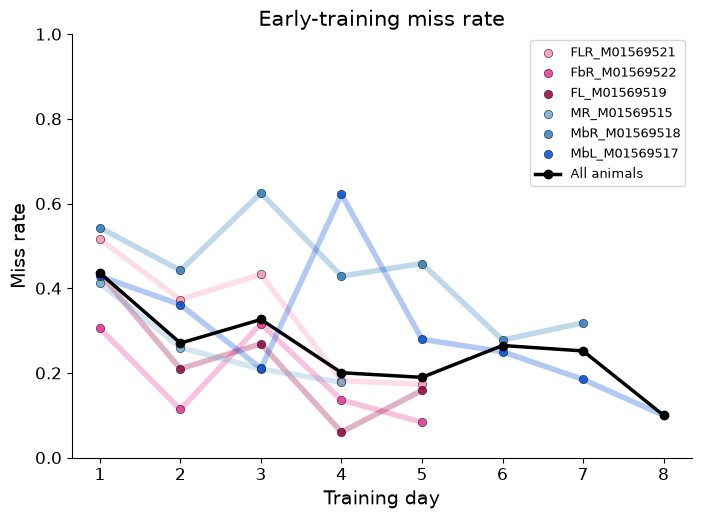

In [7]:
# Same plot for MISS rate (trials where no port was chosen, ChosenPort=-1). Coloured line
# per mouse plus the black all-animals-pooled line. No 65% line - that criterion is a
# success target, so it is not drawn here.
fig, ax, miss_summary = plot_criterion(
    trials_filtered, outcome_name='miss', outcome_labels=('Miss',), show_criterion=False,
)
fig.savefig(SAVE_DIR / 'criterion_miss_rate.svg', bbox_inches='tight')
plt.show()